# 🧠 PulseCheck - Employee Sentiment & Culture Analytics

A Python-based HR analytics tool for analyzing employee survey data using NLP and visualization techniques.

---

## 🔧 Setup

To run this notebook locally:

1. Clone this repository or download the `.ipynb` file.
2. Install dependencies:
   ```bash
   pip install -r requirements.txt

✓ Loaded 500 employee survey responses
✓ Date range: 2024-01-01 to 2024-09-30

DATASET OVERVIEW

Total Responses: 500
Departments: 8
Locations: 7
Date Range: 2024-01-01 to 2024-09-30

------------------------------------------------------------
DEPARTMENT BREAKDOWN
------------------------------------------------------------
department
Sales               69
Marketing           68
Finance             66
Customer Success    64
Engineering         60
HR                  59
Operations          57
Product             57
Name: count, dtype: int64

------------------------------------------------------------
ROLE LEVEL BREAKDOWN
------------------------------------------------------------
role_level
Senior IC                 92
Director                  92
Individual Contributor    89
Manager                   88
Team Lead                 71
Senior Manager            68
Name: count, dtype: int64

eNPS ANALYSIS

Overall eNPS: -51.0
Promoters (9-10): 75 (15.0%)
Passives (7-8): 95 (19.0%)
Detra

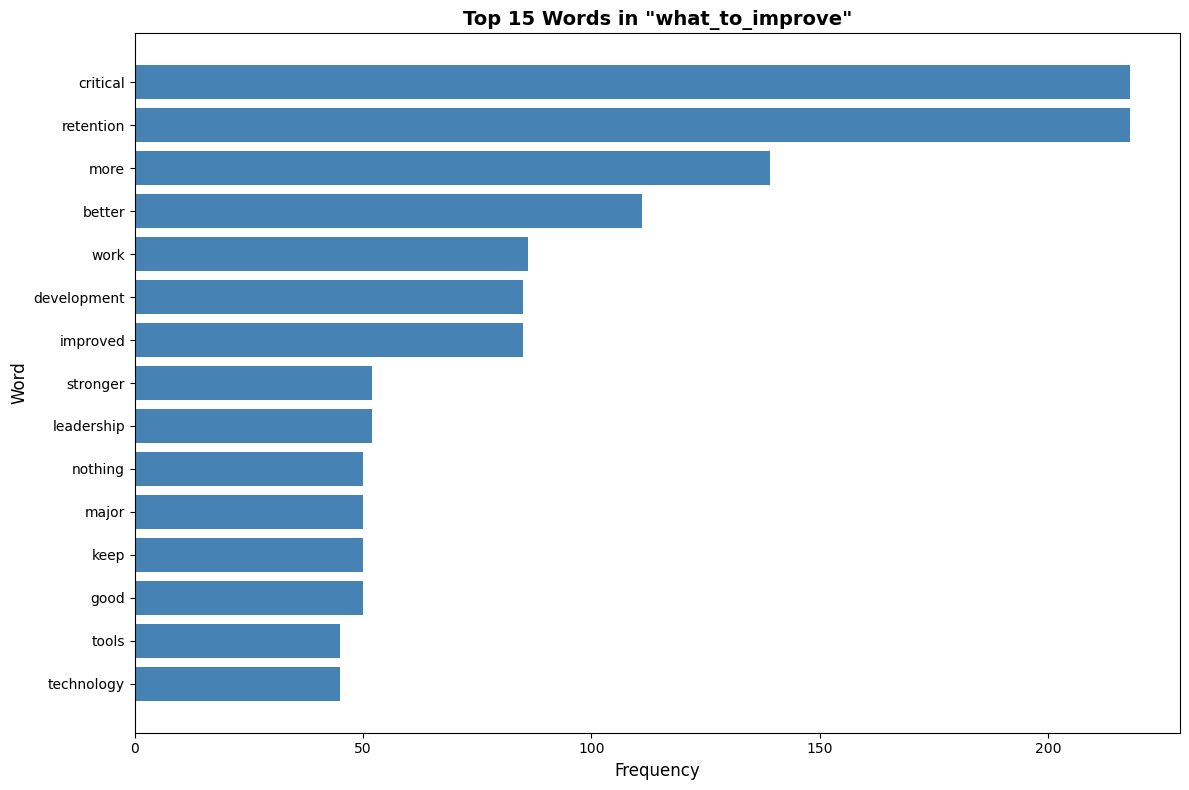


DEPARTMENT COMPARISON

Average Scores by Department (1-10 scale):
                  overall_satisfaction  work_life_balance  career_growth  \
department                                                                 
Sales                             5.68               5.61           4.64   
Operations                        5.46               5.39           4.63   
Customer Success                  5.41               5.28           4.31   
Finance                           5.23               5.26           4.30   
HR                                5.10               5.10           4.17   
Marketing                         4.96               5.15           4.03   
Engineering                       4.57               4.78           3.85   
Product                           4.18               4.18           3.39   

                  compensation_satisfaction  management_rating  \
department                                                       
Sales                                  5

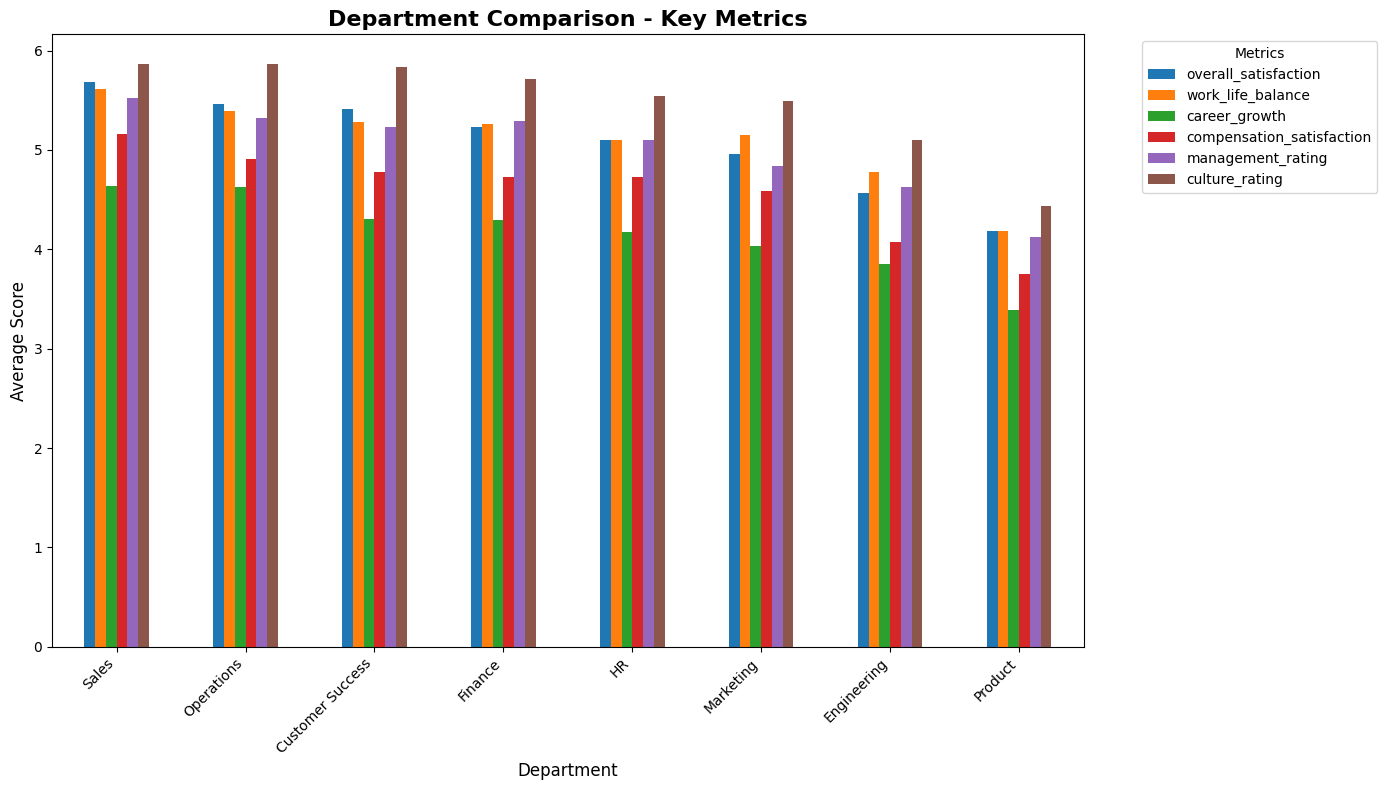


TREND ANALYSIS

Monthly Trends:
         overall_satisfaction  enps_score  work_life_balance  culture_rating
month                                                                       
2024-01                  4.15        4.00               4.18            4.47
2024-02                  4.40        4.34               4.50            4.90
2024-03                  5.50        5.27               5.47            5.68
2024-04                  4.90        4.84               4.96            5.37
2024-05                  5.54        5.38               5.34            5.92
2024-06                  4.84        4.96               5.04            5.43
2024-07                  5.47        5.32               5.56            5.86
2024-08                  5.71        5.47               5.66            6.22
2024-09                  5.25        5.09               5.25            5.60

✓ Saved visualization: trend_analysis.png


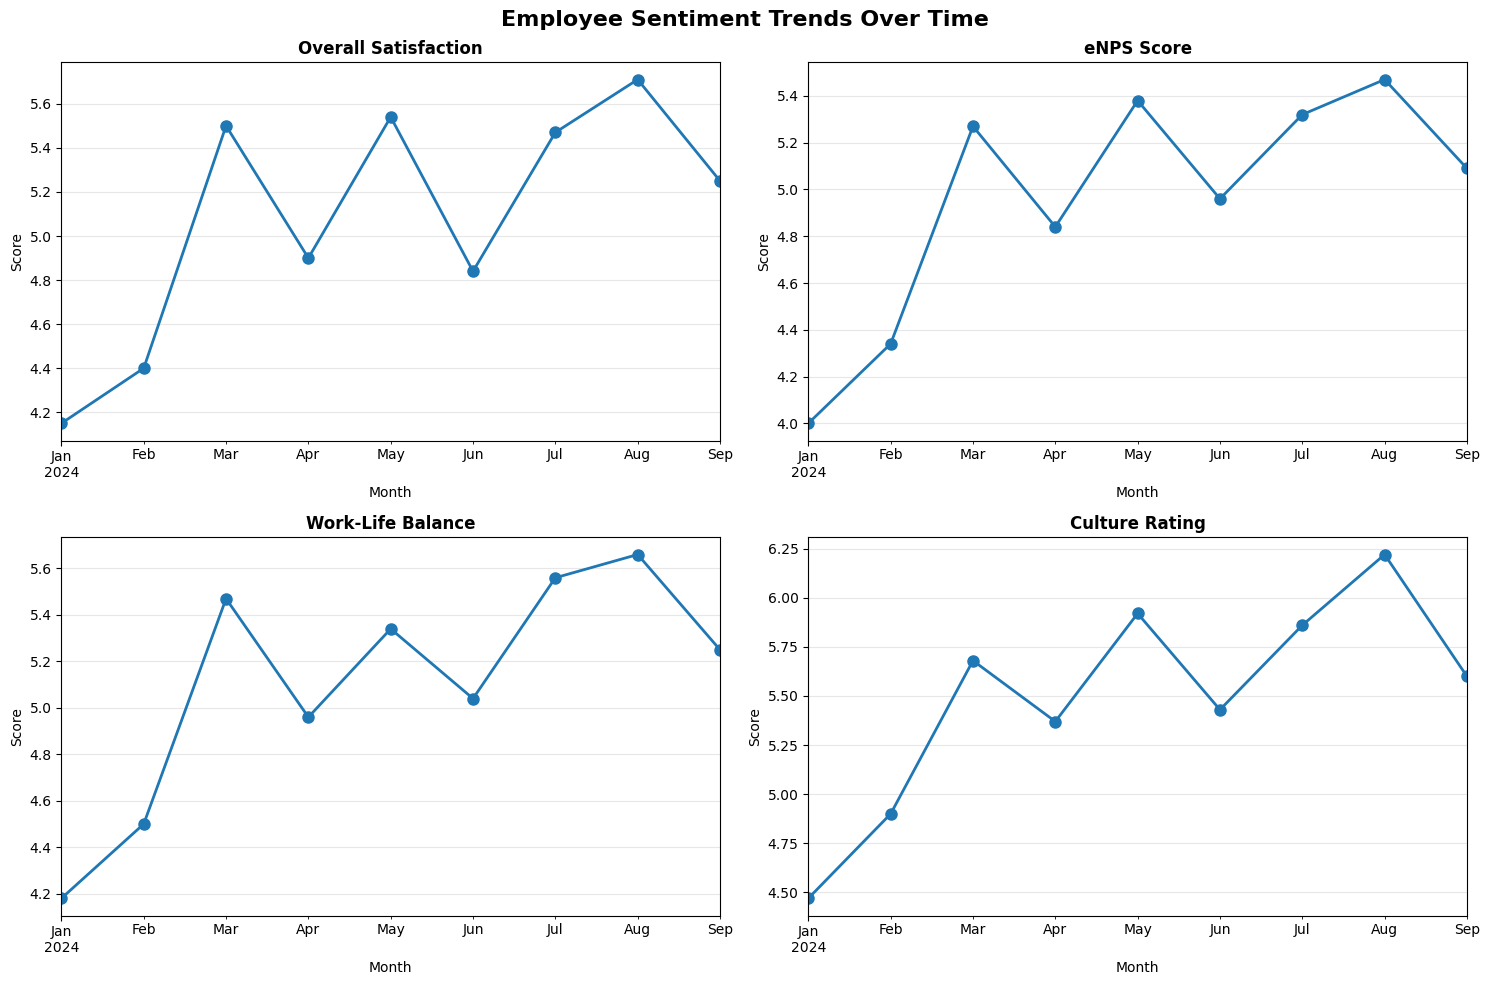


ATTRITION RISK ANALYSIS

Employees at Risk: 332 (66.4%)

At-Risk Breakdown by Department:
  Marketing: 46 employees (67.6% of department)
  Product: 44 employees (77.2% of department)
  Finance: 43 employees (65.2% of department)
  Engineering: 42 employees (70.0% of department)
  Customer Success: 40 employees (62.5% of department)
  HR: 40 employees (67.8% of department)
  Sales: 39 employees (56.5% of department)
  Operations: 38 employees (66.7% of department)

Common Issues (from improvement suggestions):
  • critical: 218 mentions
  • retention: 218 mentions
  • better: 78 mentions
  • development: 66 mentions
  • improved: 61 mentions
  • work-life: 38 mentions
  • balance: 38 mentions
  • stronger: 37 mentions
  • leadership: 37 mentions
  • tools: 36 mentions

EXECUTIVE SUMMARY

📊 KEY METRICS
   Overall Satisfaction: 5.09/10
   Average eNPS Score: 4.96/10
   Culture Rating: 5.50/10
   At-Risk Employees: 54.2%

🏆 HIGHLIGHTS
   Highest Satisfaction: Sales (5.68/10)
   Needs Att

In [10]:
#
"""
PulseCheck - Employee Sentiment & Culture Analytics Platform
A Python-based HR analytics tool for analyzing employee survey data
Author: Amira Ghazy
Date: October 2025
"""

"""
PulseCheck - Employee Sentiment & Culture Analytics
A Python-based HR analytics tool for analyzing employee survey data.
Author: Amira Ghazy
Date: October 2025
"""

# === Imports ===
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from textblob import TextBlob
import nltk
from collections import Counter
import warnings

# === Configuration ===
warnings.filterwarnings("ignore")

# Download necessary NLTK data (only first run)
nltk.download('brown', quiet=True)
nltk.download('punkt', quiet=True)


# Set style for better-looking plots
plt.rcParams['figure.figsize'] = (12, 6)


class PulseCheck:
    """Main class for employee sentiment and culture analytics"""

    def __init__(self, filepath):
        """
        Initialize PulseCheck with survey data
        
        Args:
            filepath (str): Path to CSV file with employee survey data
        """
        self.df = pd.read_csv(filepath)
        self.df['survey_date'] = pd.to_datetime(self.df['survey_date'])
        print(f"✓ Loaded {len(self.df)} employee survey responses")
        print(f"✓ Date range: {self.df['survey_date'].min().date()} to {self.df['survey_date'].max().date()}")

    def get_overview(self):
        """Display high-level overview of the data"""
        print("\n" + "="*60)
        print("DATASET OVERVIEW")
        print("="*60)
        print(f"\nTotal Responses: {len(self.df)}")
        print(f"Departments: {self.df['department'].nunique()}")
        print(f"Locations: {self.df['location'].nunique()}")
        print(f"Date Range: {self.df['survey_date'].min().date()} to {self.df['survey_date'].max().date()}")

        print("\n" + "-"*60)
        print("DEPARTMENT BREAKDOWN")
        print("-"*60)
        print(self.df['department'].value_counts())

        print("\n" + "-"*60)
        print("ROLE LEVEL BREAKDOWN")
        print("-"*60)
        print(self.df['role_level'].value_counts())

    def calculate_enps(self, segment=None):
        """
        Calcuate Employee Net Promoter Score (eNPS)

        eNPS = % Promoters (9-10) - % Detractors (0-6)

        Args:
            segment (str): Column name to segment by (e.g., 'department')
        """
        print("\n" + "="*60)
        print("eNPS ANALYSIS")
        print("="*60)

        if segment:
            results = []
            for seg_value in self.df[segment].unique():
                seg_data = self.df[self.df[segment] == seg_value]
                promoters = len(seg_data[seg_data['enps_score'] >= 9])
                detractors = len(seg_data[seg_data['enps_score'] <= 6])
                total = len(seg_data)
                enps = ((promoters - detractors) / total) * 100
                results.append({
                    segment: seg_value,
                    'eNPS': round(enps, 1),
                    'Promoters': promoters,
                    'Passives': total - promoters - detractors,
                    'Detractors': detractors
                })
            
            results_df = pd.DataFrame(results).sort_values('eNPS', ascending=False)
            print(f"\neNPS by {segment}:")
            print(results_df.to_string(index=False))
            return results_df
        else:
            promoters = len(self.df[self.df['enps_score'] >= 9])
            detractors = len(self.df[self.df['enps_score'] <= 6])
            passives = len(self.df[(self.df['enps_score'] >= 7) & (self.df['enps_score'] <= 8)])
            total = len(self.df)
            enps = ((promoters - detractors) / total) * 100

            print(f"\nOverall eNPS: {enps:.1f}")
            print(f"Promoters (9-10): {promoters} ({promoters/total*100:.1f}%)")
            print(f"Passives (7-8): {passives} ({passives/total*100:.1f}%)")
            print(f"Detractors (0-6): {detractors} ({detractors/total*100:.1f}%)")

            if enps > 30:
                print("\n✓ Excellent eNPS! Strong employee advocacy.")
            elif enps > 0:
                print("\n⚠ Good eNPS, but room for improvement.")
            else:
                print("\n✗ Negative eNPS. Urgent action needed.")
            return enps

    def analyze_sentiment(self, text_column='what_you_enjoy'):
        """
        Analyze text feedback using simple keyword analysis
        (No TextBlob required - uses basic string matching)
        """
        print("\n" + "="*60)
        print(f"TEXT FEEDBACK ANALYSIS: {text_column}")
        print("="*60)
    
        # Define positive and negative keywords
        positive_keywords = ['great', 'love', 'excellent', 'amazing', 'good', 'wonderful', 
                           'supportive', 'flexible', 'innovative', 'best', 'enjoy', 'happy']
        negative_keywords = ['poor', 'bad', 'terrible', 'lacking', 'insufficient', 'unfair',
                           'unclear', 'limited', 'burnout', 'heavy', 'inconsistent', 'lack']
    
        # Count positive and negative mentions
        positive_count = 0
        negative_count = 0
        neutral_count = 0
    
        for text in self.df[text_column].astype(str):
            text_lower = text.lower()
            has_positive = any(word in text_lower for word in positive_keywords)
            has_negative = any(word in text_lower for word in negative_keywords)
        
            if has_positive and not has_negative:
                positive_count += 1
            elif has_negative and not has_positive:
                negative_count += 1
            else:
                neutral_count += 1
    
        total = len(self.df)
        print("\nFeedback Tone Distribution:")
        print(f"  Positive: {positive_count} ({positive_count/total*100:.1f}%)")
        print(f"  Neutral:  {neutral_count} ({neutral_count/total*100:.1f}%)")
        print(f"  Negative: {negative_count} ({negative_count/total*100:.1f}%)")
    
        return {'positive': positive_count, 'neutral': neutral_count, 'negative': negative_count}

    def department_comparison(self):
        """Compare key metrics across departments"""
        print("\n" + "="*60)
        print("DEPARTMENT COMPARISON")
        print("="*60)
        
        metrics = ['overall_satisfaction', 'work_life_balance',
                  'career_growth', 'compensation_satisfaction',
                  'management_rating', 'culture_rating']

        dept_avg = self.df.groupby('department')[metrics].mean().round(2)
        dept_avg['avg_score'] = dept_avg.mean(axis=1).round(2)
        dept_avg = dept_avg.sort_values('avg_score', ascending=False)

        print("\nAverage Scores by Department (1-10 scale):")
        print(dept_avg)

        # Visualize
        plt.figure(figsize=(14,8))
        dept_avg[metrics].plot(kind='bar', ax=plt.gca())
        plt.title('Department Comparison - Key Metrics', fontsize=16, fontweight='bold')
        plt.xlabel('Department', fontsize=12)
        plt.ylabel('Average Score', fontsize=12)
        plt.legend(title='Metrics', bbox_to_anchor=(1.05, 1), loc='upper left')
        plt.xticks(rotation=45, ha='right')
        plt.tight_layout()
        plt.savefig('department_comparison.png', dpi=300, bbox_inches='tight')
        print("\n✓ Saved visualization: department_comparison.png")
        plt.show()

        return dept_avg

    def trend_analysis(self):
        """Analyze sentiment trends over time"""
        print("\n" + "="*60)
        print("TREND ANALYSIS")
        print("="*60)

        # Montly aggregation
        self.df['month'] = self.df['survey_date'].dt.to_period('M')
        monthly_trends = self.df.groupby('month').agg({
            'overall_satisfaction': 'mean',
            'enps_score': 'mean',
            'work_life_balance': 'mean',
            'culture_rating': 'mean'
        }).round(2)

        print("\nMonthly Trends:")
        print(monthly_trends)

        #Visualize
        fig, axes = plt.subplots(2, 2, figsize=(15, 10))
        fig.suptitle('Employee Sentiment Trends Over Time', fontsize=16, fontweight='bold')

        metrics = ['overall_satisfaction', 'enps_score', 'work_life_balance', 'culture_rating']
        titles = ['Overall Satisfaction', 'eNPS Score', 'Work-Life Balance', 'Culture Rating']

        for ax, metric, title in zip(axes.flat, metrics, titles):
            monthly_trends[metric].plot(ax=ax, marker='o', linewidth=2, markersize=8)
            ax.set_title(title, fontsize=12, fontweight='bold')
            ax.set_xlabel('Month', fontsize=10)
            ax.set_ylabel('Score', fontsize=10)
            ax.grid(True, alpha=0.3)

        plt.tight_layout()
        plt.savefig('trend_analysis.png', dpi=300, bbox_inches='tight')
        print("\n✓ Saved visualization: trend_analysis.png")
        plt.show()

        return monthly_trends

    def word_frequency_analysis(self, text_column='what_to_improve', top_n=15):
        """
        Analyze most common words in text responses

        Args:
            text_column (str): Column to analyze
            top_n (int): Number of top words to display
        """
        print("\n" + "="*60)
        print("="*60)

        # Combine all text
        all_text = ' '.join(self.df[text_column].astype(str).values)

        # Basic work tokenization (remove common stop words)
        stop_words = {'the', 'a', 'an', 'and', 'or', 'but', 'in', 'on', 'at', 'to', 'for',
                      'of', 'with', 'is', 'are', 'was', 'were', 'be', 'been', 'being', 'this',
                      'that', 'these', 'those', 'it', 'its', 'as', 'by', 'from', 'has', 'have'}

        words = [word.lower().strip('.,!?;:') for word in all_text.split()
                 if word.lower() not in stop_words and len(word) > 3]

        # Count frequencies
        word_counts = {}
        for word in words:
            word_counts[word] = word_counts.get(word, 0) + 1

        # Sort and get top N
        sorted_words = sorted(word_counts.items(), key=lambda x: x[1], reverse=True)[:top_n]

        print(f"\nTop {top_n} Most Common Words:")
        for word, count in sorted_words:
            print(f"   {word}: {count}")

        # Visualize
        words_list = [w[0] for w in sorted_words]
        counts_list = [w[1] for w in sorted_words]

        plt.figure(figsize=(12, 8))
        plt.barh(words_list, counts_list, color='steelblue')
        plt.xlabel('Frequency', fontsize=12)
        plt.ylabel('Word', fontsize=12)
        plt.title(f'Top {top_n} Words in "{text_column}"', fontsize=14, fontweight='bold')
        plt.gca().invert_yaxis()
        plt.tight_layout()
        plt.savefig(f'word_frequency_{text_column}.png', dpi=300, bbox_inches='tight')
        print(f"\n✓ Saved visualization: word_frequency_{text_column}.png")
        plt.show()

        return sorted_words

    def identify_at_risk_employees(self, threshold=5):
        """
        Identify employees at risk of leaving based on low scores
        
        Args:
            threshold (int): Satisfaction score below which employee is at risk
        """
        print("\n" + "="*60)
        print("ATTRITION RISK ANALYSIS")
        print("="*60)
        
        at_risk = self.df[
            (self.df['overall_satisfaction'] <= threshold) |
            (self.df['enps_score'] <= 6)
        ].copy()
        
        print(f"\nEmployees at Risk: {len(at_risk)} ({len(at_risk)/len(self.df)*100:.1f}%)")
        
        print("\nAt-Risk Breakdown by Department:")
        dept_risk = at_risk.groupby('department').size().sort_values(ascending=False)
        for dept, count in dept_risk.items():
            total_in_dept = len(self.df[self.df['department'] == dept])
            pct = (count / total_in_dept) * 100
            print(f"  {dept}: {count} employees ({pct:.1f}% of department)")
        
        print("\nCommon Issues (from improvement suggestions):")
        at_risk_improvements = ' '.join(at_risk['what_to_improve'].astype(str).values)
        words = [w.lower() for w in at_risk_improvements.split() if len(w) > 4]
        from collections import Counter
        common_issues = Counter(words).most_common(10)
        for issue, count in common_issues:
            print(f"  • {issue}: {count} mentions")
        
        return at_risk

    def generate_executive_summary(self):
        """Generate a comprehensive executive summary"""
        print("\n" + "="*60)
        print("EXECUTIVE SUMMARY")
        print("="*60)

        #Key Metrics
        avg_satisfaction = self.df['overall_satisfaction'].mean()
        avg_enps = self.df['enps_score'].mean()
        avg_culture = self.df['culture_rating'].mean()
        at_risk_pct = len(self.df[self.df['overall_satisfaction'] <= 5]) / len(self.df) * 100

        print(f"\n📊 KEY METRICS")
        print(f"   Overall Satisfaction: {avg_satisfaction:.2f}/10")
        print(f"   Average eNPS Score: {avg_enps:.2f}/10")
        print(f"   Culture Rating: {avg_culture:.2f}/10")
        print(f"   At-Risk Employees: {at_risk_pct:.1f}%")

        # Top Performing Department
        dept_avg = self.df.groupby('department')['overall_satisfaction'].mean()
        best_dept = dept_avg.idxmax()
        worst_dept = dept_avg.idxmin()

        print(f"\n🏆 HIGHLIGHTS")
        print(f"   Highest Satisfaction: {best_dept} ({dept_avg[best_dept]:.2f}/10)")
        print(f"   Needs Attention: {worst_dept} ({dept_avg[worst_dept]:.2f}/10)")

        print(f"\n⚠️ RECOMMENDED ACTIONS")
        if avg_satisfaction < 6:
            print("   1. URGENT: Address low satisfaction scores")
        if at_risk_pct > 20:
            print("   2. HIGH PRIORITY: Retention initiatives needed")
        if worst_dept:
            print(f"   3. Focus on {worst_dept} department improvement")

        print("\n" + "="*60)

if __name__ == "__main__":
    FILE_PATH = r"Github Project 2/employee_survey_data.csv"

    try:
        # Create the PulseCheck object with your data
        pulse = PulseCheck(FILE_PATH)

        # Run all analyses
        pulse.get_overview()
        pulse.calculate_enps()
        pulse.calculate_enps(segment='department')
        pulse.analyze_sentiment('what_you_enjoy')
        pulse.analyze_sentiment('what_to_improve')
        pulse.word_frequency_analysis('what_to_improve', top_n=15) 
        pulse.department_comparison()
        pulse.trend_analysis()  
        pulse.identify_at_risk_employees()  
        pulse.generate_executive_summary()

        print("\n" + "="*60)
        print("✓ ANALYSIS COMPLETE")
        print("="*60)
        print("\nGenerated files:")
        print("  • department_comparison.png")
        print("  • trend_analysis.png")  # ← ADD THIS
        print("  • word_frequency_what_to_improve.png")  # ← ADD THIS

    except FileNotFoundError:
        print(f"\n✗ Error: Could not find '{FILE_PATH}'")
        print("\n💡 SOLUTION:")
        print("   1. Make sure you download the CSV file")
        print("   2. Put the CSV file in the same folder as this Python script")
        print("   3. Update the FILE_PATH line above to match your filename")
        print("\n   Examples:")
        print('   FILE_PATH = "employee_survey_data.csv" # Same folder')
        print('   FILE_PATH = "data/employee_survey_data.csv" #In data folder')

    except Exception as e:
        print(f"\n✗ Error: {e}")
        print("Please check your data format and try again")